# Week 5
source for AV: https://www.linkedin.com/pulse/practical-guide-adversarial-validation-lu%C3%ADs-fernando-torres/

Goals of this notebook:
* Get test, train, validation split of data, stratified on isFraud
* Perform Adversarial Validation to see what is in test, train, and validation sets when compared to each other

Limitation: To preserve RAM for analysis, I used a sample of the data instead of the whole thing. However, I feel this sample is good enough to analyze the test/train split. 

# Week 6

Revised to include one-hot encoding (see one-hot and clean_transaction notebooks) instead of enabling categorical variables on xgbm. My RAM kept failing, so I had to break up a lot of my work into seperate notebooks :).

In [1]:
# set up
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from xgboost import XGBClassifier, plot_importance
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt


In [2]:
# load data
transaction = pd.read_csv('/content/transaction_clean.csv')

Step 1: Test/Train/Validation Split
* Train: 60%
* Test: 20%
* Validation: 20%

Commented out because if I run the split, I don't have the RAM for the AV and vice versa. 

Stratified on isFraud

In [3]:
# get data ready for split
X = transaction.drop('isFraud', axis=1)
y = transaction['isFraud']

In [4]:
# split 1: isolate test set - DO NOT TOUCH
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# split 2: isolate validation set
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42, stratify=y_train)


In [5]:
# export train and test as csv
# train = pd.concat([X_train, y_train], axis = 1)
# test = pd.concat([X_test, y_test], axis = 1)
# val = pd.concat([X_val, y_val], axis = 1)

# remember to split a second time 50/50 when doing the actual analysis to preserve the test/validation split
# train.to_csv(path_or_buf='/content/train_transaction.csv')
# test.to_csv(path_or_buf='/content/test_transaction.csv')
# val.to_csv(path_or_buf = '/content/val_transaction.csv')

## Adversarial Validation

Adversarial Validation sees how similar the test, train, and validation sets are to each other. The goal of this analysis to see where the test and train sets differ to prevent overfitting in the future

In [6]:
# add flags to show what data set the records come from
# 0 = train, 1 = test/val

X_train['isTrain'] = 1
X_test['isTrain'] = 0

X_all = pd.concat([X_train, X_test], axis = 0)
df = X_all.sample(frac = 1, random_state = 472)


In [7]:
# Splitting Data
X_av = df.drop(['isTrain'], axis = 1)
y_av = df['isTrain']

In [ ]:
# create kfolds for validation
cv = StratifiedKFold(n_splits = 6, shuffle = True, random_state = 472)

In [ ]:
# build model to predict if part of the test set or the train set 
xgb_model = XGBClassifier(max_depth=3,
                          learning_rate = 0.01,
                          n_estimators = 100,
                          objective = 'binary:logistic',
                          enable_categorical=False,
                          random_state = 472)

In [ ]:
# get av scores for each cv 
av_scores = []

cv = cv.split(X_av,y_av)

# test the model, show the ROC AUC scores to observe model accuracy
for _, (train_val, test_val) in enumerate(cv):
    X_train = X_av.iloc[train_val]
    X_test = X_av.iloc[test_val]
    y_train = y_av.iloc[train_val]
    y_test = y_av.iloc[test_val]

    xgb_model.fit(X_train, y_train)

    y_pred = xgb_model.predict_proba(X_test)[:,1]
    score = roc_auc_score(y_test, y_pred)
    av_scores.append(score)

    print(f"Fold AUC Score: {score:.5f}")

Fold AUC Score: 0.50568
Fold AUC Score: 0.49998
Fold AUC Score: 0.49858
Fold AUC Score: 0.50378
Fold AUC Score: 0.49687
Fold AUC Score: 0.50266


Having a low fold AUC score is good, because it means that the model is having a hard time differentiating between the test and train sets. Therfore, there is no glaring issue with the split and both represent each other well. It's about as good as random guessing.

Text(0, 0.5, 'True Positive Rate')

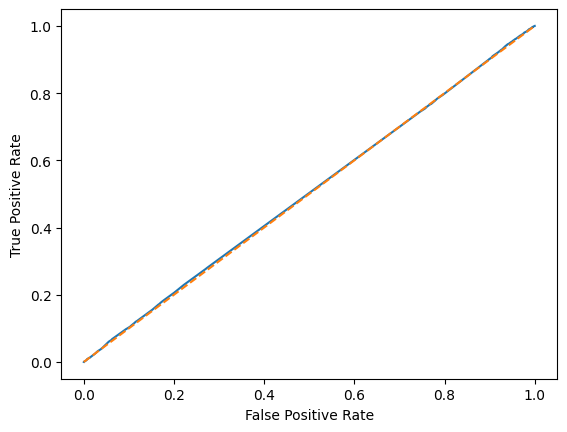

In [11]:
# plot the AUC scores

mean_scores = np.mean(av_scores)
false_positives, true_positives, _ = roc_curve(y_test, y_pred)
plt.plot(false_positives, true_positives, label = f'ROC Curve (AUC = {mean_scores})')
plt.plot([0, 1], [0, 1], '--', label='Random Guessing', color='C1')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

Even though its accuracy is low and telling the test/train data apart is not easy, we can see which features are most important in differentiating the two datasets. It makes sense that one-hot encoded columns from the P_emaildomain would allow for better prediction, becuase some of them are not common and there could randomly be more of one in the training set than the test set. Since we discussed dropping this column in past discussions, I'm not placing too much pressure on it being a good predictor of test/train set. Also, it being an important feature of a model that is about as good as random guessing does not mean that it is an feature distributed unequally across the test/train split. 

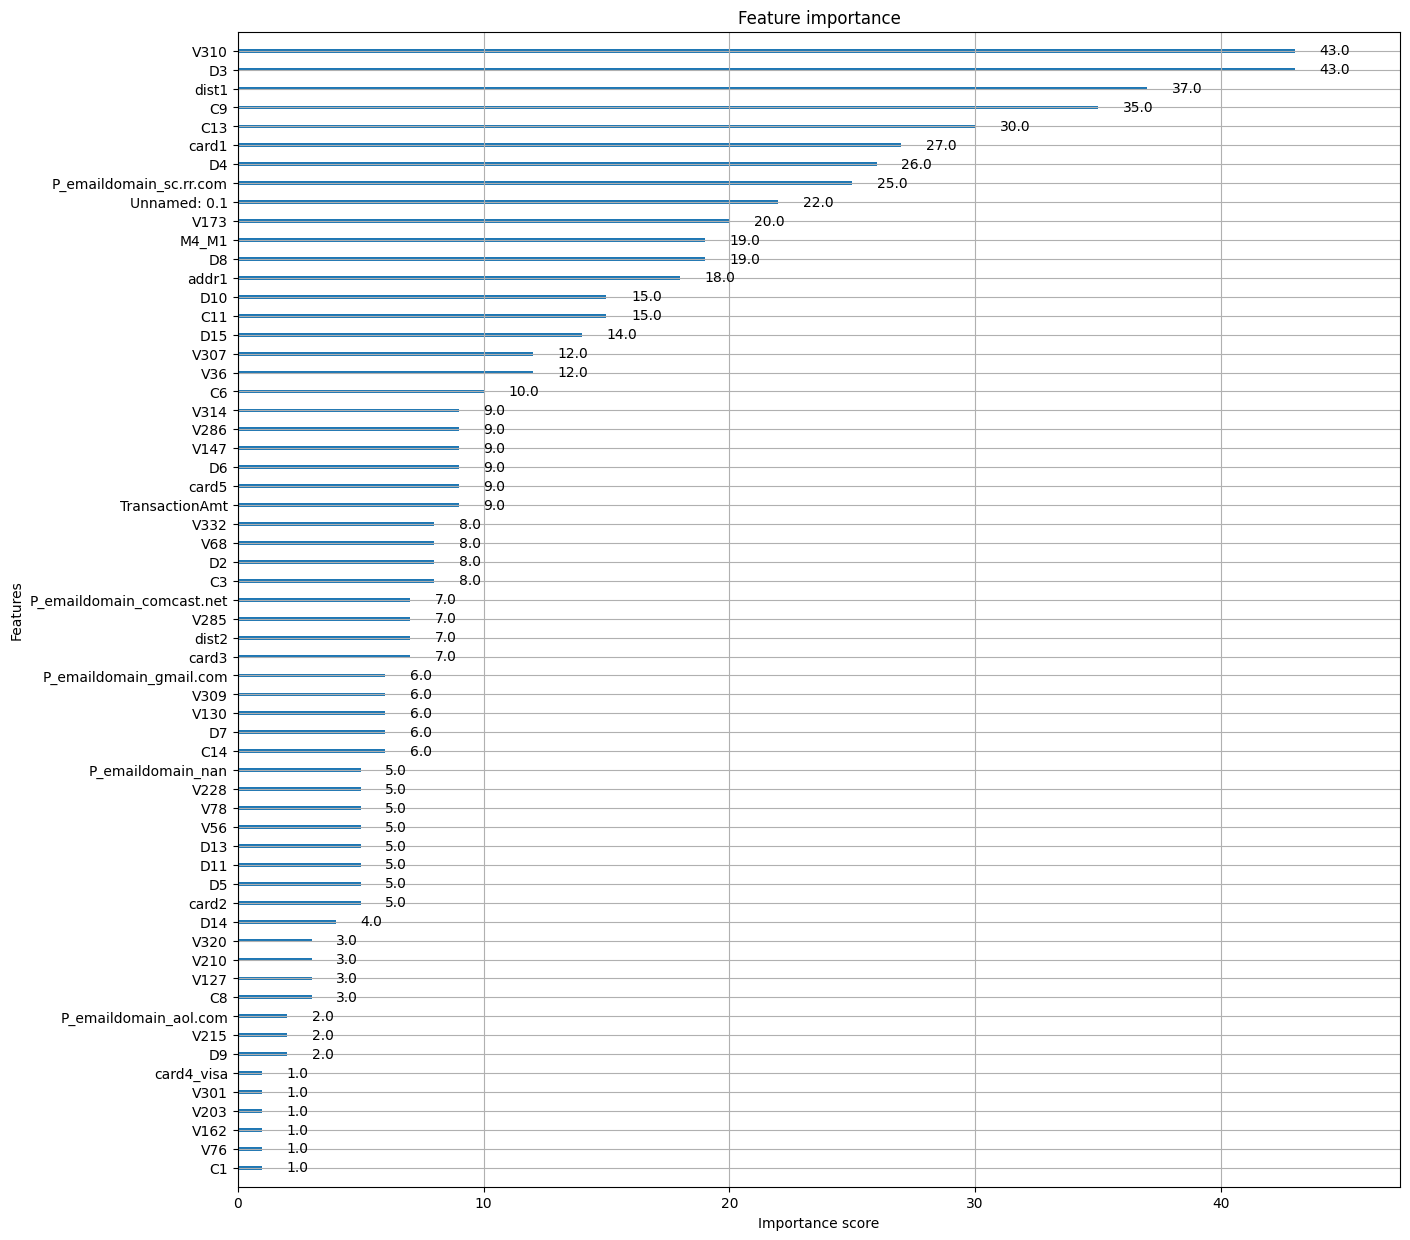

In [12]:
# understand which features are most important to the model, which tells us about which features are similar across the test/train split
ax = plot_importance(xgb_model)
fig = ax.figure
fig.set_size_inches(15, 15)